# Matplotlib 子图和布局

本笔记本演示 Matplotlib 中的子图布局和多种排列方式。

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

## 1. 使用 subplots 创建子图

subplots() 是创建子图的最常用方法。

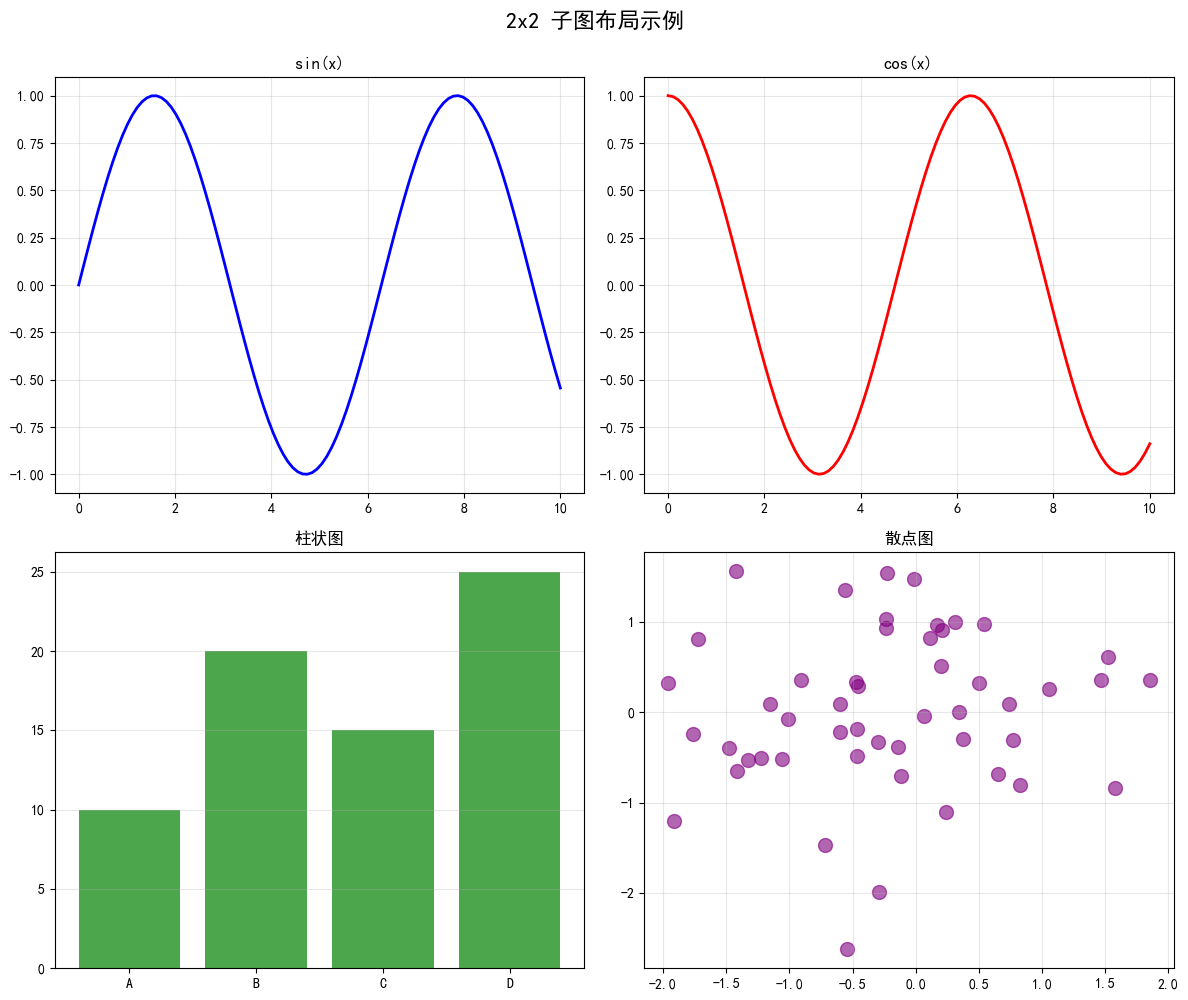

In [3]:
# 创建 2x2 的子图
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

x = np.linspace(0, 10, 100)

# 第一个子图 - 线图
axes[0, 0].plot(x, np.sin(x), color='blue', linewidth=2)
axes[0, 0].set_title('sin(x)', fontsize=12, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

# 第二个子图 - 线图
axes[0, 1].plot(x, np.cos(x), color='red', linewidth=2)
axes[0, 1].set_title('cos(x)', fontsize=12, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# 第三个子图 - 柱状图
categories = ['A', 'B', 'C', 'D']
values = [10, 20, 15, 25]
axes[1, 0].bar(categories, values, color='green', alpha=0.7)
axes[1, 0].set_title('柱状图', fontsize=12, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3, axis='y')

# 第四个子图 - 散点图
np.random.seed(42)
axes[1, 1].scatter(np.random.randn(50), np.random.randn(50), 
                   alpha=0.6, s=100, color='purple')
axes[1, 1].set_title('散点图', fontsize=12, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

# 调整布局
fig.suptitle('2x2 子图布局示例', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

C:\Users\zhang\AppData\Local\Temp\ipykernel_41092\854027914.py:20: RuntimeWarning: divide by zero encountered in log
  axes[2].plot(x, np.log(x), color='green', linewidth=2)
C:\Users\zhang\AppData\Local\Temp\ipykernel_41092\854027914.py:27: UserWarning: Glyph 178 (\N{SUPERSCRIPT TWO}) missing from font(s) SimHei.
  plt.tight_layout()
d:\Programs\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 178 (\N{SUPERSCRIPT TWO}) missing from font(s) SimHei.
  fig.canvas.print_figure(bytes_io, **kw)


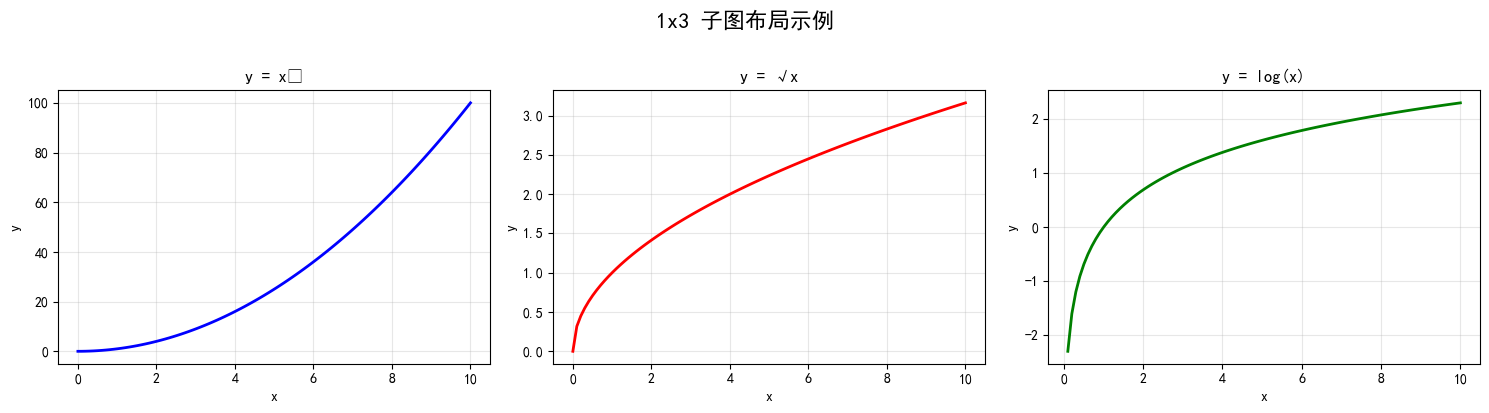

In [4]:
# 创建 1x3 的子图（横向排列）
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 第一个子图
x = np.linspace(0, 10, 100)
axes[0].plot(x, x ** 2, color='blue', linewidth=2)
axes[0].set_title('y = x²', fontsize=12, fontweight='bold')
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')
axes[0].grid(True, alpha=0.3)

# 第二个子图
axes[1].plot(x, np.sqrt(x), color='red', linewidth=2)
axes[1].set_title('y = √x', fontsize=12, fontweight='bold')
axes[1].set_xlabel('x')
axes[1].set_ylabel('y')
axes[1].grid(True, alpha=0.3)

# 第三个子图
axes[2].plot(x, np.log(x), color='green', linewidth=2)
axes[2].set_title('y = log(x)', fontsize=12, fontweight='bold')
axes[2].set_xlabel('x')
axes[2].set_ylabel('y')
axes[2].grid(True, alpha=0.3)

fig.suptitle('1x3 子图布局示例', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

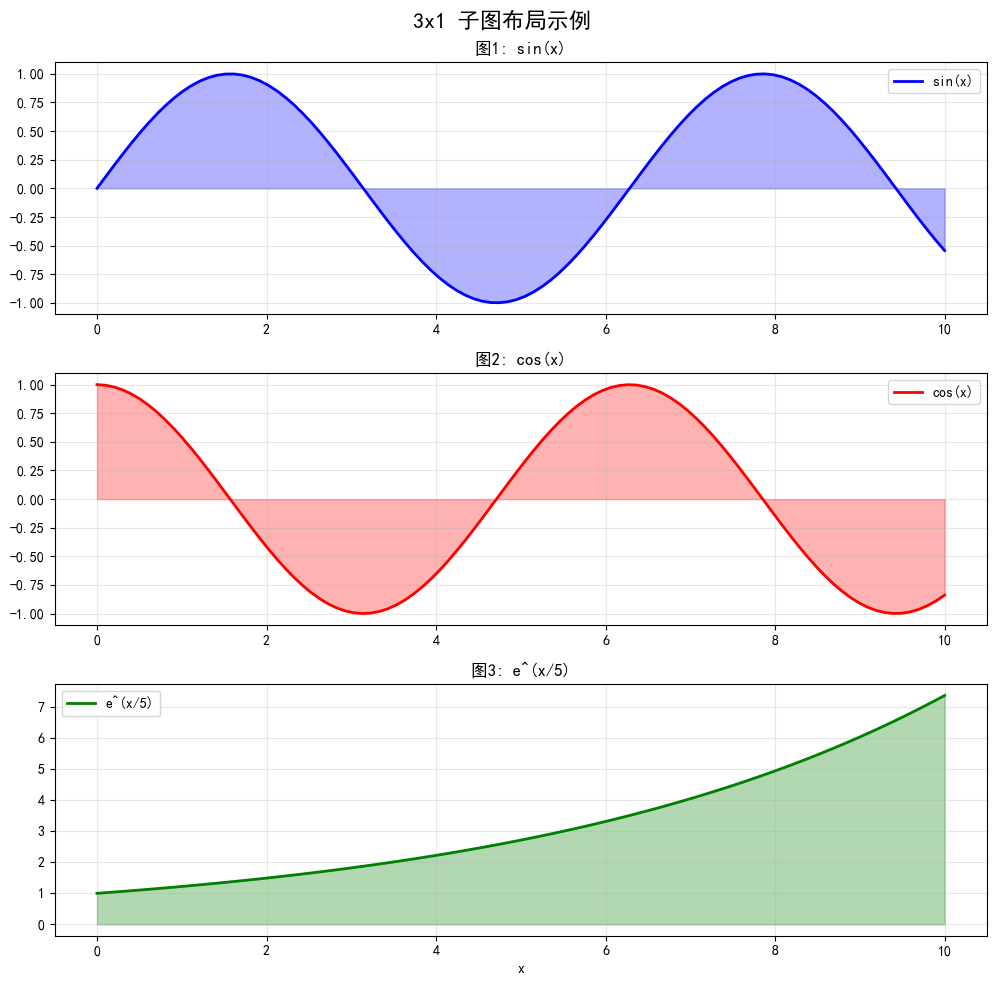

In [5]:
# 创建 3x1 的子图（纵向排列）
fig, axes = plt.subplots(3, 1, figsize=(10, 10))

x = np.linspace(0, 10, 100)

# 顶部子图
axes[0].fill_between(x, np.sin(x), alpha=0.3, color='blue')
axes[0].plot(x, np.sin(x), color='blue', linewidth=2, label='sin(x)')
axes[0].set_title('图1: sin(x)', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# 中间子图
axes[1].fill_between(x, np.cos(x), alpha=0.3, color='red')
axes[1].plot(x, np.cos(x), color='red', linewidth=2, label='cos(x)')
axes[1].set_title('图2: cos(x)', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

# 底部子图
axes[2].fill_between(x, np.exp(x/5), alpha=0.3, color='green')
axes[2].plot(x, np.exp(x/5), color='green', linewidth=2, label='e^(x/5)')
axes[2].set_title('图3: e^(x/5)', fontsize=12, fontweight='bold')
axes[2].set_xlabel('x')
axes[2].grid(True, alpha=0.3)
axes[2].legend()

fig.suptitle('3x1 子图布局示例', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## 2. GridSpec - 灵活的布局

使用 GridSpec 可以创建不规则的子图布局。

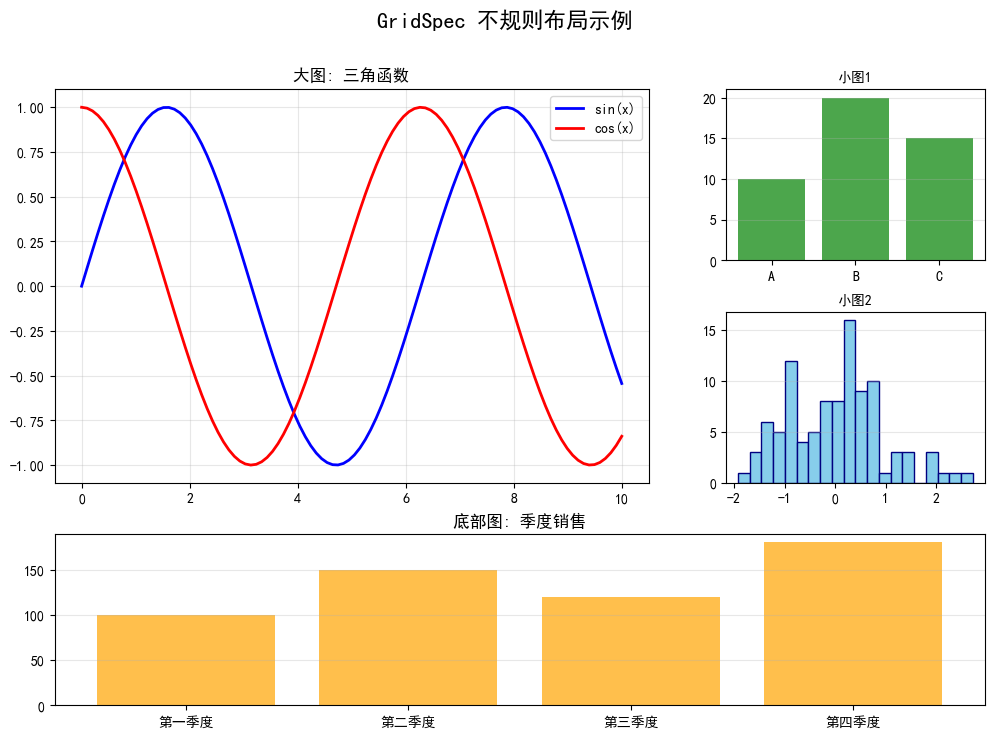

In [6]:
# 使用 GridSpec 创建不规则布局
fig = plt.figure(figsize=(12, 8))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# 大的子图占据左上 2x2 区域
ax1 = fig.add_subplot(gs[0:2, 0:2])
x = np.linspace(0, 10, 100)
ax1.plot(x, np.sin(x), 'b-', linewidth=2, label='sin(x)')
ax1.plot(x, np.cos(x), 'r-', linewidth=2, label='cos(x)')
ax1.set_title('大图: 三角函数', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend()

# 右上的小图
ax2 = fig.add_subplot(gs[0, 2])
ax2.bar(['A', 'B', 'C'], [10, 20, 15], color='green', alpha=0.7)
ax2.set_title('小图1', fontsize=10, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

# 右中的小图
ax3 = fig.add_subplot(gs[1, 2])
ax3.hist(np.random.randn(100), bins=20, color='skyblue', edgecolor='navy')
ax3.set_title('小图2', fontsize=10, fontweight='bold')
ax3.grid(True, alpha=0.3, axis='y')

# 底部占据整行
ax4 = fig.add_subplot(gs[2, :])
categories = ['第一季度', '第二季度', '第三季度', '第四季度']
values = [100, 150, 120, 180]
ax4.bar(categories, values, color='orange', alpha=0.7)
ax4.set_title('底部图: 季度销售', fontsize=12, fontweight='bold')
ax4.grid(True, alpha=0.3, axis='y')

fig.suptitle('GridSpec 不规则布局示例', fontsize=16, fontweight='bold')
plt.show()

In [7]:
## 3. 共享轴

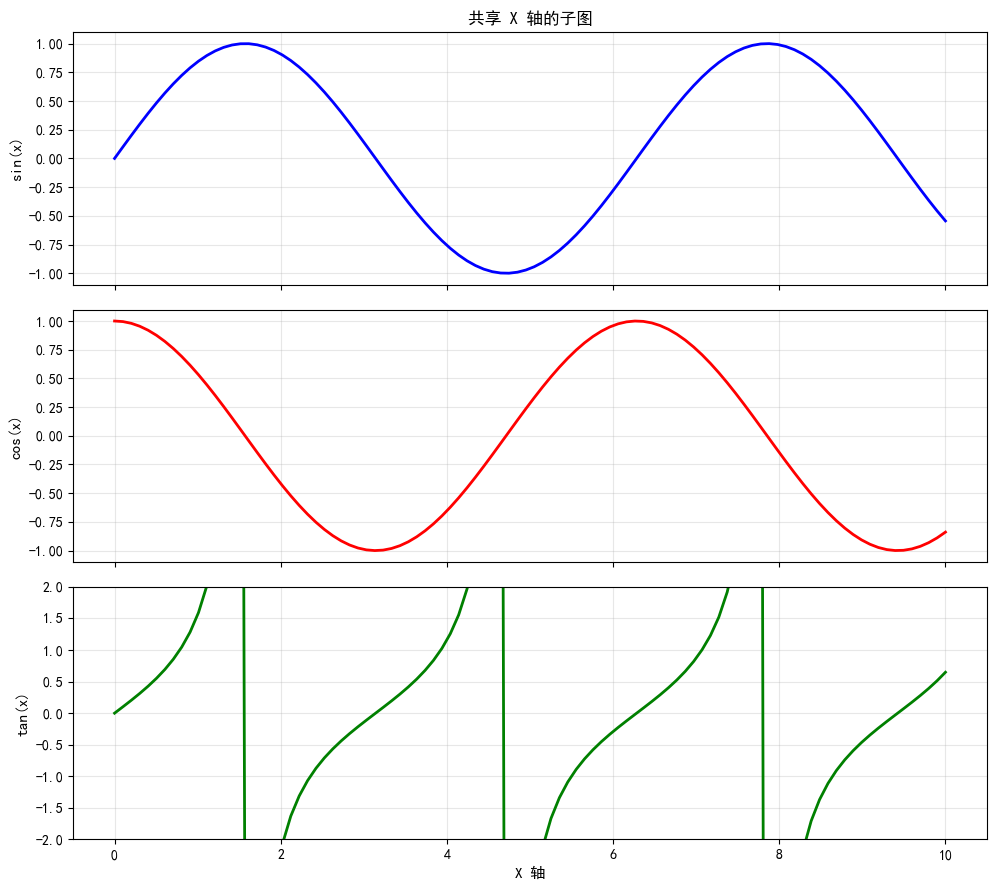

In [8]:
# 共享 X 轴
fig, axes = plt.subplots(3, 1, figsize=(10, 9), sharex=True)

x = np.linspace(0, 10, 100)

axes[0].plot(x, np.sin(x), color='blue', linewidth=2)
axes[0].set_ylabel('sin(x)', fontsize=11)
axes[0].grid(True, alpha=0.3)
axes[0].set_title('共享 X 轴的子图', fontsize=12, fontweight='bold')

axes[1].plot(x, np.cos(x), color='red', linewidth=2)
axes[1].set_ylabel('cos(x)', fontsize=11)
axes[1].grid(True, alpha=0.3)

axes[2].plot(x, np.tan(x), color='green', linewidth=2)
axes[2].set_ylabel('tan(x)', fontsize=11)
axes[2].set_xlabel('X 轴', fontsize=11)
axes[2].set_ylim(-2, 2)  # 限制 Y 轴范围
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

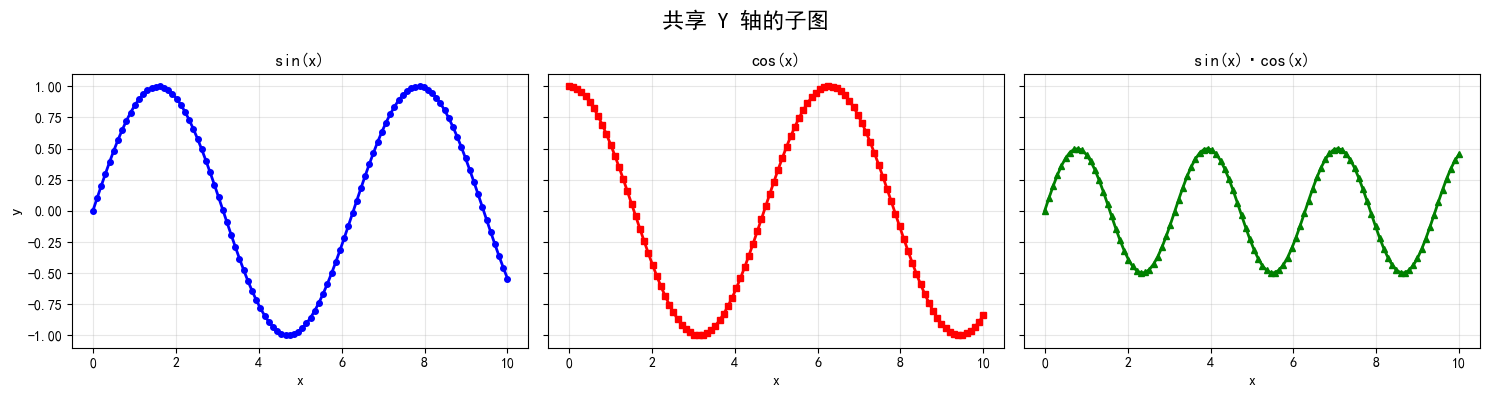

In [9]:
# 共享 Y 轴
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

x = np.linspace(0, 10, 100)

axes[0].plot(x, np.sin(x), color='blue', linewidth=2, marker='o', markersize=4)
axes[0].set_title('sin(x)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('x')
axes[0].set_ylabel('y', fontsize=11)
axes[0].grid(True, alpha=0.3)

axes[1].plot(x, np.cos(x), color='red', linewidth=2, marker='s', markersize=4)
axes[1].set_title('cos(x)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('x')
axes[1].grid(True, alpha=0.3)

axes[2].plot(x, np.sin(x) * np.cos(x), color='green', linewidth=2, marker='^', markersize=4)
axes[2].set_title('sin(x)·cos(x)', fontsize=12, fontweight='bold')
axes[2].set_xlabel('x')
axes[2].grid(True, alpha=0.3)

fig.suptitle('共享 Y 轴的子图', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. 双 Y 轴（twinx）

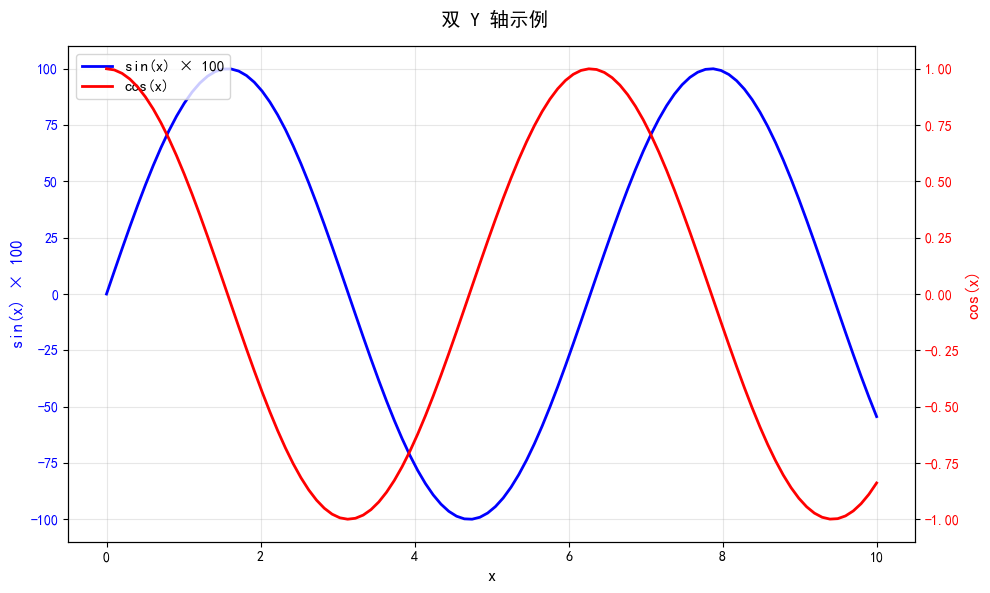

In [11]:
# 使用 twinx 创建双 Y 轴
fig, ax1 = plt.subplots(figsize=(10, 6))

x = np.linspace(0, 10, 100)
y1 = np.sin(x) * 100  # 幅度调整

# 左侧 Y 轴
color = 'blue'
ax1.set_xlabel('x', fontsize=12)
ax1.set_ylabel('sin(x) × 100', color=color, fontsize=12)
line1 = ax1.plot(x, y1, color=color, linewidth=2, label='sin(x) × 100')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, alpha=0.3)

# 创建第二个 Y 轴
ax2 = ax1.twinx()

# 右侧 Y 轴
color = 'red'
y2 = np.cos(x)
ax2.set_ylabel('cos(x)', color=color, fontsize=12)
line2 = ax2.plot(x, y2, color=color, linewidth=2, label='cos(x)')
ax2.tick_params(axis='y', labelcolor=color)

# 添加图例
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left', fontsize=11)

fig.suptitle('双 Y 轴示例', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()